In [1]:
import sys
sys.path.append("../src")

import importlib
import re

import pandas as pd
import GOenrichment as ge

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/diff/proneural_rna_diff.csv",
    "Classical": "../data/interim/diff/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/diff/mesenchymal_rna_diff.csv"
}

pathway_genes_df = pd.read_csv(
    "../data/interim/network_stat/complex_pathway_gene_list.csv",
    low_memory=False
)

apoptosis_genes = set(
    pathway_genes_df.loc[
        pathway_genes_df["pathway"].fillna("").str.lower().eq("apoptosis"),
        "gene"
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .tolist()
)

def add_apoptosis_gene_count(go_df, apoptosis_gene_set):
    if go_df.empty:
        out = go_df.copy()
        out["Apoptosis Gene count"] = 0
        return out

    gene_col_candidates = [
        "Genes",
        "genes",
        "geneID",
        "Lead_genes"
    ]

    gene_col = next(
        (col for col in gene_col_candidates if col in go_df.columns),
        None
    )

    if gene_col is None:
        raise ValueError(
            "Could not find a gene-list column. Available columns: "
            + ", ".join(go_df.columns.astype(str))
        )

    out = go_df.copy()

    def split_genes(gene_text):
        if pd.isna(gene_text):
            return []

        return [
            g.strip()
            for g in re.split(r"[;/,]", str(gene_text))
            if g and g.strip()
        ]

    out["Apoptosis Gene count"] = out[gene_col].apply(
        lambda x: len(
            {g.upper() for g in split_genes(x)} & apoptosis_gene_set
        )
    )

    return out


Proneural
Significant genes after filtering: 3417
Proneural: BP
Proneural: CC
Proneural: MF


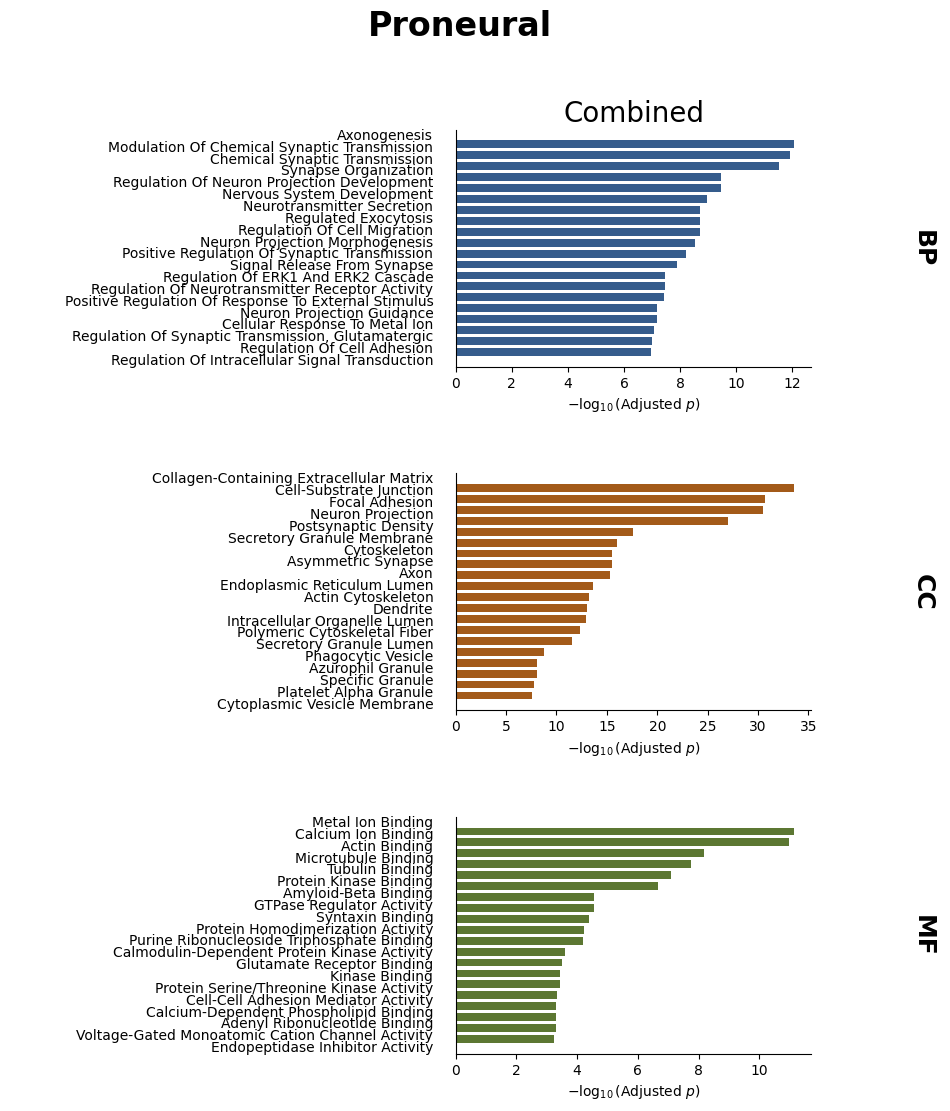


Classical
Significant genes after filtering: 3767
Classical: BP
Classical: CC
Classical: MF


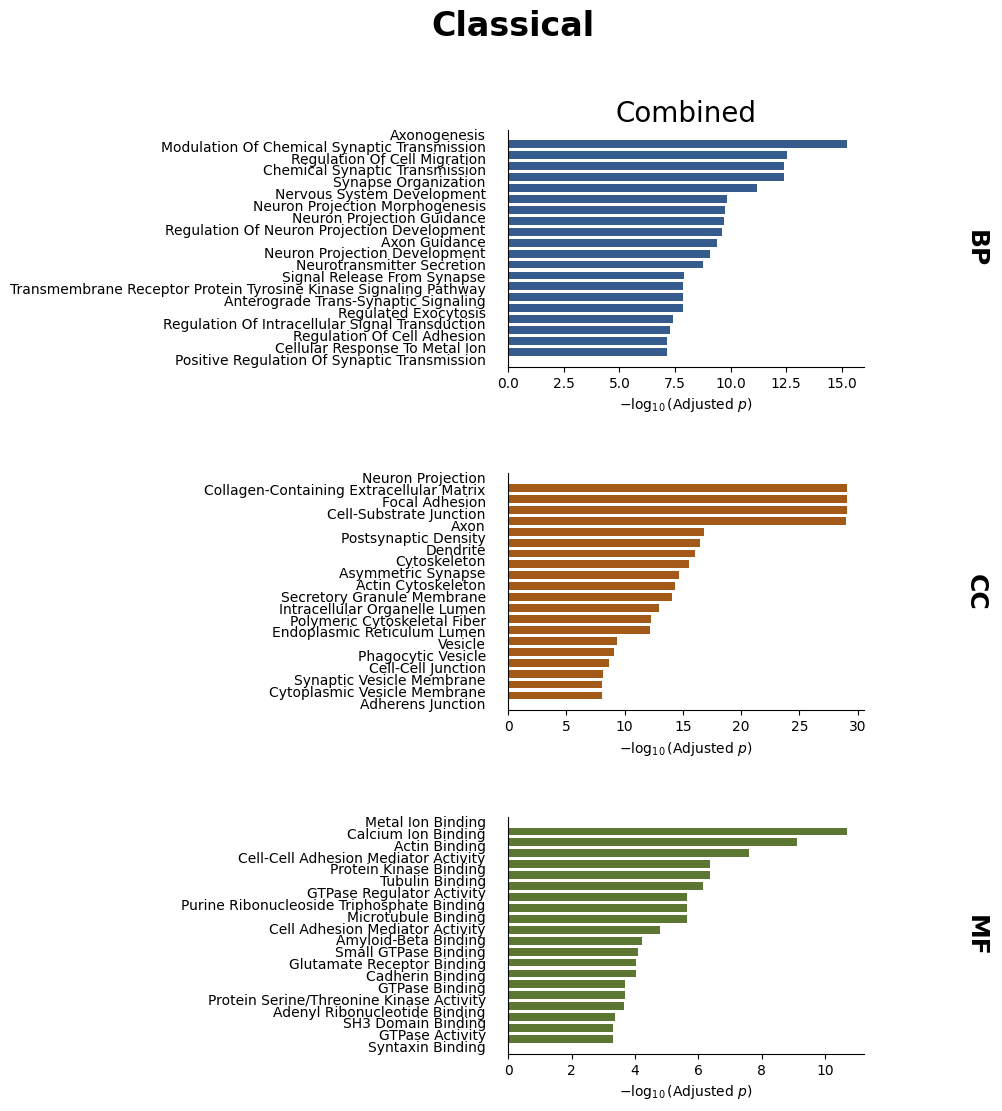


Mesenchymal
Significant genes after filtering: 4071
Mesenchymal: BP
Mesenchymal: CC
Mesenchymal: MF


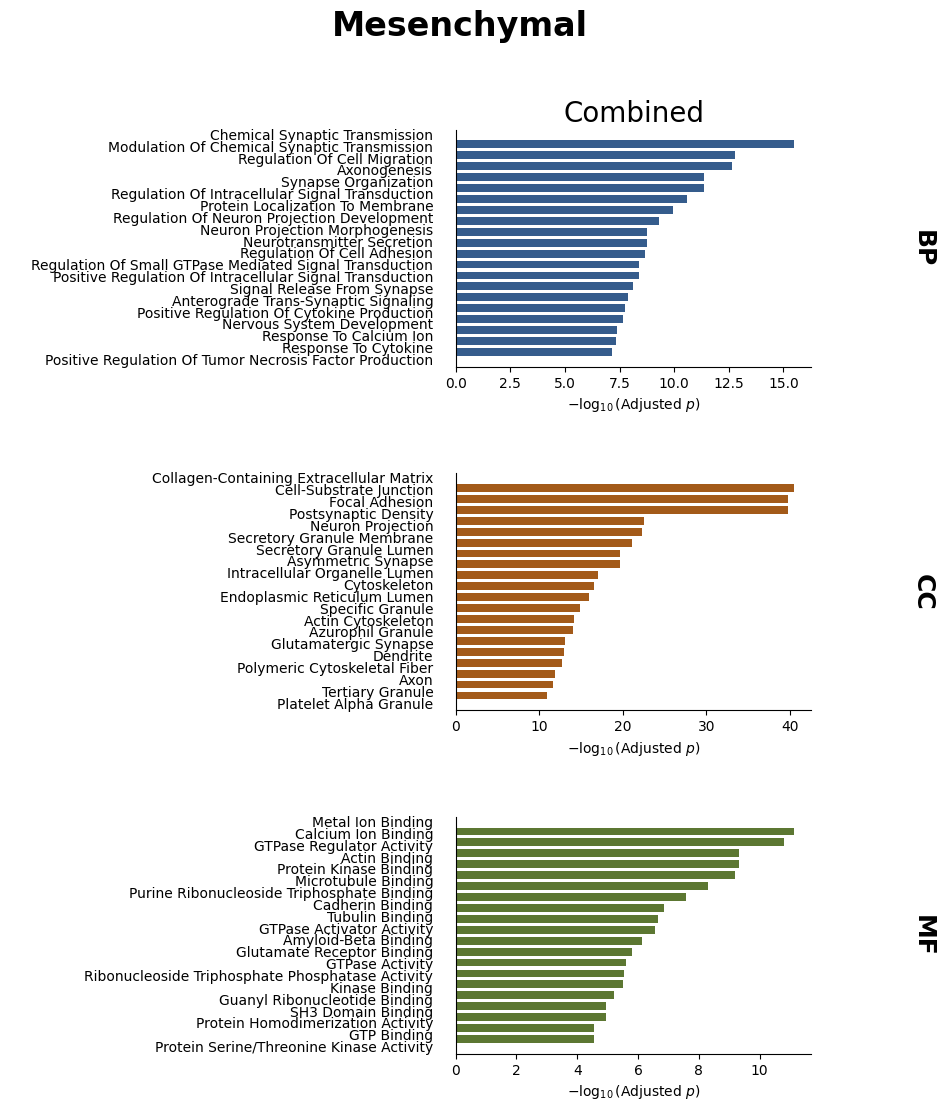

In [2]:
go_combined = {}

for subtype, file in files.items():
    go_combined[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="combined"
    )


In [3]:
for subtype in go_combined:
    bp = go_combined[subtype]["BP"].copy()

    significant = bp[bp["Adjusted P-value"] < 0.05]

    print(
        f"{subtype}: {len(significant)} significantly enriched GO BP terms"
    )

Proneural: 728 significantly enriched GO BP terms
Classical: 705 significantly enriched GO BP terms
Mesenchymal: 809 significantly enriched GO BP terms


In [7]:
mesenchymal_keywords = [
    "apop",
    "programmed cell death",
    "pyrop",
    "necrop",
    "ferrop",
    "autophag",
    "cell death",
    "casp",
    "BCL2",
    "BAX",
    "intrinsic apoptotic"
]

mesen_pattern = "|".join(mesenchymal_keywords)

mes = go_combined["Mesenchymal"]["BP"].copy()

mes["Rank"] = range(1, len(mes) + 1)

hits_mes = mes[
        mes["Term"].str.contains(mesen_pattern, case=False, na=False)
    ]

hits_mes = add_apoptosis_gene_count(hits_mes, apoptosis_genes)

print(f"\n===== Mesenchymal =====")

if hits_mes.empty:
    print("No matching GO terms found.")
else:
    print(
        hits_mes[[
            "Rank",
            "Term",
            "Adjusted P-value",
            "Apoptosis Gene count"
        ]].to_string(index=False)
    )



===== Mesenchymal =====
 Rank                                                                                                   Term  Adjusted P-value  Apoptosis Gene count
   89                                                  Positive Regulation Of Apoptotic Process (GO:0043065)          0.000041                    20
   94                                              Positive Regulation Of Programmed Cell Death (GO:0043068)          0.000052                    18
  126                                                           Regulation Of Apoptotic Process (GO:0042981)          0.000130                    23
  157                                                  Negative Regulation Of Apoptotic Process (GO:0043066)          0.000233                    11
  184                                           Positive Regulation Of Apoptotic Cell Clearance (GO:2000427)          0.000394                     0
  203                                                    Regulation Of Neuron Apo

In [8]:
classical_keywords = [
    "apop",
    "programmed cell death",
    "pyrop",
    "necrop",
    "ferrop",
    "autophag",
    "cell death",
    "casp",
    "BCL2",
    "BAX",
    "intrinsic apoptotic"
]

clas_pattern = "|".join(classical_keywords)

clas = go_combined["Classical"]["BP"].copy()

clas["Rank"] = range(1, len(clas) + 1)

hits_clas = clas[
        clas["Term"].str.contains(clas_pattern, case=False, na=False)
    ]

hits_clas = add_apoptosis_gene_count(hits_clas, apoptosis_genes)

print(f"\n===== Classical =====")

if hits_clas.empty:
    print("No matching GO terms found.")
else:
    print(
        hits_clas[[
            "Rank",
            "Term",
            "Adjusted P-value",
            "Apoptosis Gene count"
        ]].to_string(index=False)
    )



===== Classical =====
 Rank                                                                                                 Term  Adjusted P-value  Apoptosis Gene count
  138                                         Positive Regulation Of Apoptotic Cell Clearance (GO:2000427)          0.000305                     0
  179                                                         Regulation Of Apoptotic Process (GO:0042981)          0.000709                    18
  229                                            Positive Regulation Of Programmed Cell Death (GO:0043068)          0.001563                    15
  247                                                Negative Regulation Of Apoptotic Process (GO:0043066)          0.002027                     9
  266                                                  Regulation Of Neuron Apoptotic Process (GO:0043523)          0.002345                     1
  374                                                Positive Regulation Of Apoptotic Process (

In [9]:
proneural_keywords = [
    "apop",
    "programmed cell death",
    "pyrop",
    "necrop",
    "ferrop",
    "autophag",
    "cell death",
    "casp",
    "BCL2",
    "BAX",
    "intrinsic apoptotic"
]

bp = go_combined["Proneural"]["BP"].copy()
bp["Rank"] = range(1, len(bp) + 1)

proneural_hits = bp[
    bp["Term"].str.contains(
        "|".join(proneural_keywords),
        case=False,
        na=False
    )
]

proneural_hits = add_apoptosis_gene_count(
    proneural_hits,
    apoptosis_genes
)

print("\n===== Proneural =====")

if proneural_hits.empty:
    print("No matching GO terms found.")
else:
    print(
        proneural_hits[[
            "Rank",
            "Term",
            "Adjusted P-value",
            "Apoptosis Gene count"
        ]].to_string(index=False)
    )


===== Proneural =====
 Rank                                                                                                   Term  Adjusted P-value  Apoptosis Gene count
  117                                           Positive Regulation Of Apoptotic Cell Clearance (GO:2000427)          0.000177                     0
  326                                              Positive Regulation Of Programmed Cell Death (GO:0043068)          0.005955                    14
  393                                                           Regulation Of Apoptotic Process (GO:0042981)          0.009207                    15
  444                                                  Positive Regulation Of Apoptotic Process (GO:0043065)          0.013784                    15
  448                                        Positive Regulation Of Leukocyte Apoptotic Process (GO:2000108)          0.014046                     1
  519                                                    Regulation Of Apoptotic Ce

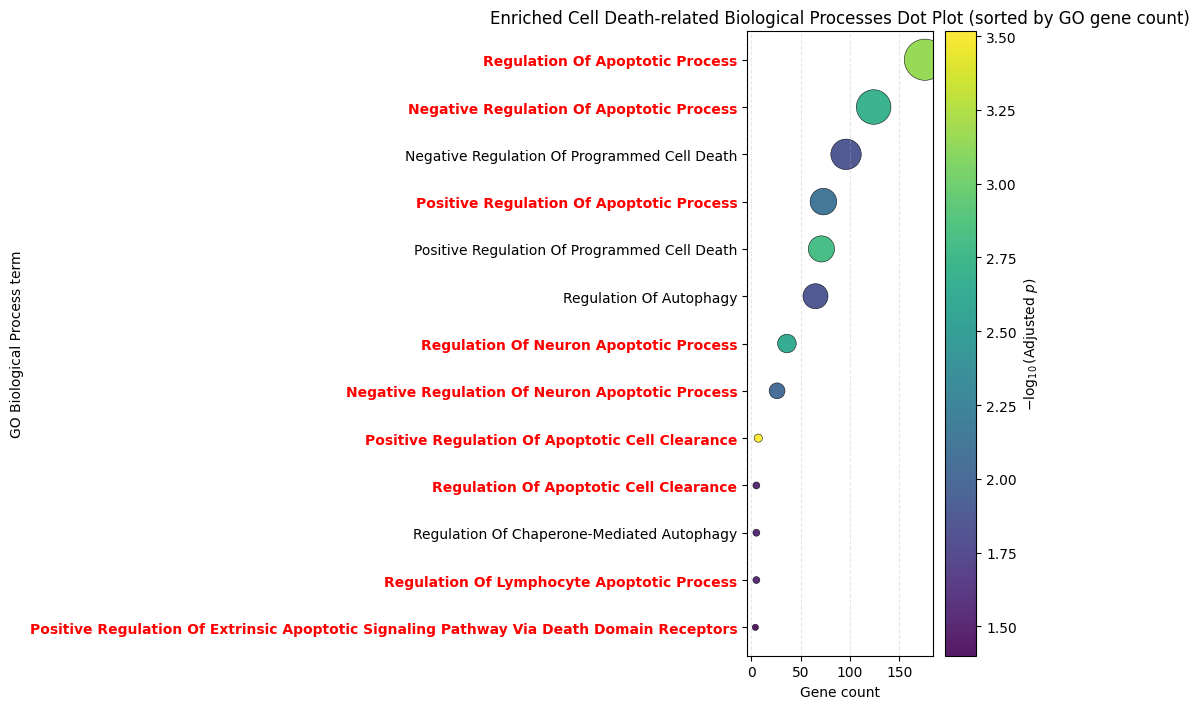

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Use the GO term list generated in cell 4
classical_bp = hits_clas.copy()

if classical_bp.empty:
    print("No Classical GO terms from cell 4 to plot.")
else:
    # Clean GO term labels
    classical_bp["Term_clean"] = classical_bp["Term"].str.replace(
        r"\s*\(GO:\d+\)",
        "",
        regex=True
    )

    # Use gene count from GO enrichment output
    if "Count" in classical_bp.columns:
        classical_bp["Gene count"] = pd.to_numeric(
            classical_bp["Count"],
            errors="coerce"
        )
    elif "Overlap" in classical_bp.columns:
        classical_bp["Gene count"] = pd.to_numeric(
            classical_bp["Overlap"].astype(str).str.split("/").str[0],
            errors="coerce"
        )
    else:
        gene_col = next(
            (c for c in ["Genes", "genes", "geneID", "Lead_genes"] if c in classical_bp.columns),
            None
        )
        if gene_col is None:
            raise ValueError(
                "No usable gene count column found (expected one of: Count, Overlap, Genes/geneID)."
            )
        classical_bp["Gene count"] = classical_bp[gene_col].fillna("").apply(
            lambda s: len([g for g in re.split(r"[;/,]", str(s)) if g.strip()])
        )

    # Color uses -log10(adjusted p-value)
    classical_bp["neg_log10_adj_p"] = -np.log10(
        classical_bp["Adjusted P-value"].clip(lower=1e-300)
    )

    # Sort by GO enrichment gene count
    plot_df = classical_bp.sort_values(
        "Gene count",
        ascending=False
    ).reset_index(drop=True)

    fig_height = max(6, 0.4 * len(plot_df) + 2)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    scatter = ax.scatter(
        plot_df["Gene count"],
        plot_df["Term_clean"],
        s=plot_df["Gene count"] * 5,
        c=plot_df["neg_log10_adj_p"],
        cmap="viridis",
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )

    # Color the GO-term text labels
    turquoise = "red"

    # Define which GO terms are considered apoptosis-related.
    # Add/remove terms here as needed.
    apoptosis_keywords = [
        "apoptosis",
        "apoptotic",
        #"programmed cell death",
        #"cell death",
        "intrinsic apoptotic",
        "extrinsic apoptotic",
        #"caspase",
    ]

    # Plot first so the tick labels exist
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df["Term_clean"])

    # Highlight apoptosis-related terms ONLY in the text
    for tick, term in zip(ax.get_yticklabels(), plot_df["Term_clean"]):

        term_lower = term.lower()

        if any(keyword in term_lower for keyword in apoptosis_keywords):
            tick.set_color(turquoise)
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(r"$-\log_{10}(\mathrm{Adjusted}\ p)$")

    ax.set_xlabel("Gene count")
    ax.set_ylabel("GO Biological Process term")
    ax.set_title("Enriched Cell Death-related Biological Processes Dot Plot (sorted by GO gene count)")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    # Highest gene count at top
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()